# Peak shape and microstructure

A peak's width has two sources: the instrument, and the specimen's own small crystallites and strain.
To measure the specimen you have to know the instrument first.
We calibrate a synthetic instrument on a standard, save it, and use it to measure crystallite size and microstrain in a synthetic sample.
Because both patterns are synthetic, we know the answers and can grade the fit.

**You need** `pip install "rietx[viz]"`.
Notebook 02 introduces plans and the parameter table.

**Runtime** is under a minute on a laptop.

## How widths combine

Each peak is a pseudo-Voigt: a Gaussian and a Lorentzian convolved.
The two parts combine differently.
Gaussian *variances* add, so the Gaussian width squared is

$$\Gamma_G^2 = (U + U_s)\tan^2\theta + V\tan\theta + W + P/\cos^2\theta$$

Lorentzian *widths* add, so the Lorentzian width is

$$\Gamma_L = (X + X_s)/\cos\theta + (Y + Y_s)\tan\theta$$

U, V, W, X and Y belong to the instrument.
The specimen adds P and X_s, which go as 1/cos θ and carry crystallite size, and U_s and Y_s, which go as tan θ and carry microstrain.
In rietx the specimen terms are each phase's `gauss_size`, `lor_size`, `gauss_strain` and `lor_strain`.

The instrument and specimen terms have the same angular shapes.
A fit on one pattern cannot tell them apart, so the instrument is measured separately, on a standard with no size or strain broadening of its own.

## Two synthetic patterns

The standard is LaB₆ and the sample is CeO₂.
We write each structure as a short CIF.

In [1]:
import tempfile
from pathlib import Path

import numpy as np

import rietx as rx
from rietx.model.profiles.caglioti import (
    size_coefficient_for_size,
    strain_coefficient_for_microstrain,
)

work = Path(tempfile.mkdtemp())


def structure_from_rows(name, space_group, a, rows):
    """A cubic structure from a few atom rows, by way of a CIF."""
    cell = "".join(f"_cell_length_{k} {a}\n" for k in "abc")
    cell += "".join(f"_cell_angle_{k} 90\n" for k in ("alpha", "beta", "gamma"))
    atoms = "".join(" ".join(map(str, row)) + "\n" for row in rows)
    path = work / f"{name}.cif"
    path.write_text(
        f"data_{name}\n_space_group_name_H-M_alt '{space_group}'\n{cell}"
        "loop_\n_atom_site_label\n_atom_site_type_symbol\n_atom_site_fract_x\n"
        "_atom_site_fract_y\n_atom_site_fract_z\n_atom_site_B_iso_or_equiv\n" + atoms,
        encoding="utf-8")
    return rx.Structure.from_cif(path)


lab6 = structure_from_rows("LaB6", "P m -3 m", 4.15689,
                           [("La1", "La", 0, 0, 0, 0.25), ("B1", "B", 0.1996, 0.5, 0.5, 0.35)])
ceo2 = structure_from_rows("CeO2", "F m -3 m", 5.411,
                           [("Ce1", "Ce", 0, 0, 0, 0.3), ("O1", "O", 0.25, 0.25, 0.25, 0.6)])

Next, the true instrument and the true sample broadening.
These numbers are the answers the fits should recover.

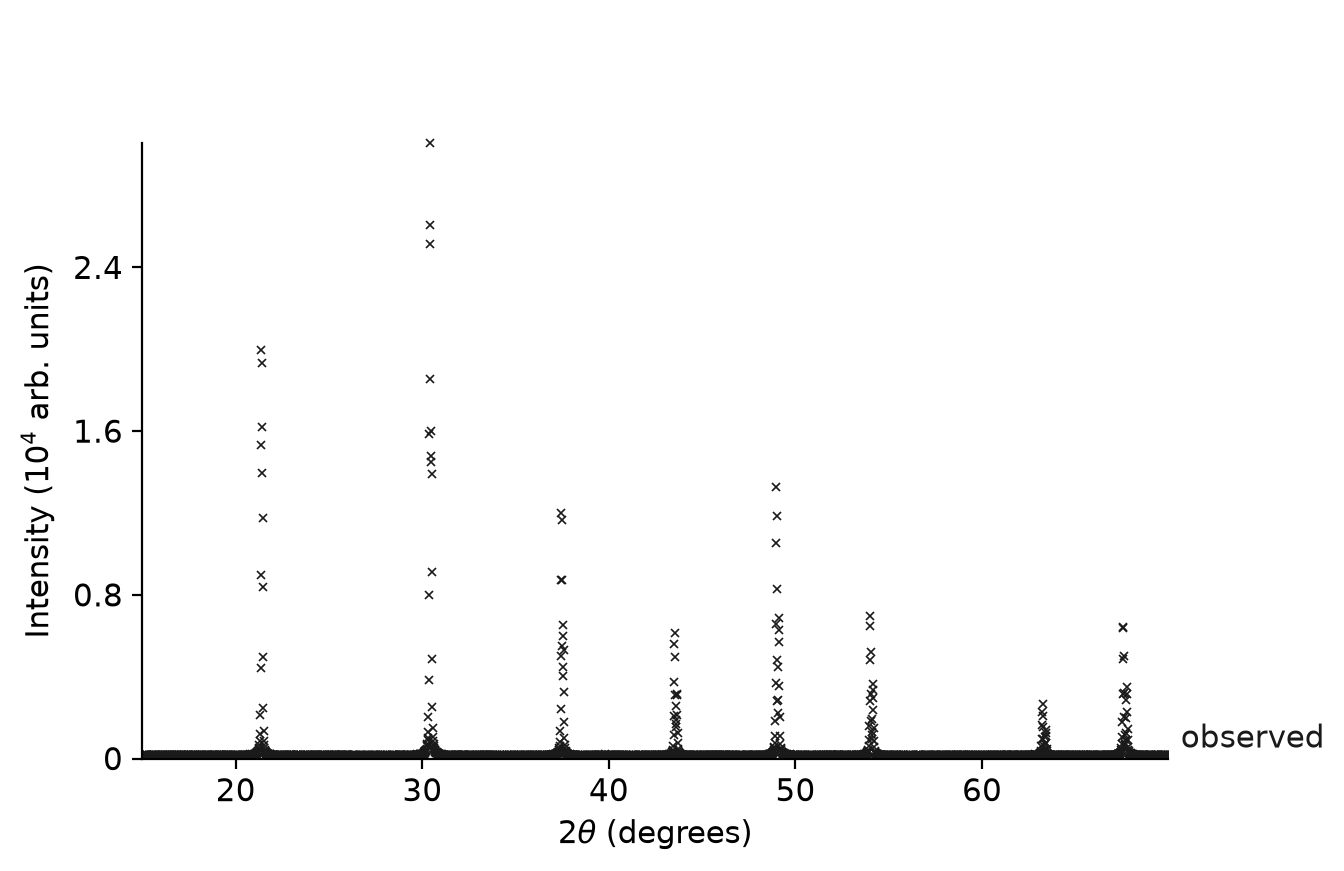

In [2]:
TRUE_PROFILE = dict(u=0.004, v=-0.003, w=0.003, x=0.015, y=0.02)  # deg² and deg, 2θ
TRUE_ZERO = 0.02             # degrees 2θ
TRUE_SIZE = 300.0            # Å, coherent domain size
TRUE_STRAIN = 1.0e-3         # Δd/d

instrument = rx.Instrument.bragg_brentano(radiation="CuKa")
for name, value in TRUE_PROFILE.items():
    getattr(instrument.profile, name).value = value
instrument.zero_shift.value = TRUE_ZERO
instrument.background = rx.BackgroundChebyshev.with_terms(1)
instrument.background.coefficients[0].value = 150.0

wavelength = instrument.source.lines[0].wavelength.value
ceo2.phases[0].lor_size.value = size_coefficient_for_size(TRUE_SIZE, wavelength)
ceo2.phases[0].lor_strain.value = strain_coefficient_for_microstrain(TRUE_STRAIN)

two_theta = np.arange(15, 130, 0.015)
rng = np.random.default_rng(0)


def measure(structure, strongest_peak):
    """Poisson counts from the true model, scaled so the strongest peak has the counts given."""
    structure = structure.model_copy(deep=True)
    y = rx.Refinement(structure, instrument).predict(two_theta)
    structure.phases[0].scale.value *= strongest_peak / (y.max() - 150.0)
    y = rx.Refinement(structure, instrument).predict(two_theta)
    return rx.PatternData(two_theta=two_theta, intensity=rng.poisson(y).astype(float))


standard_data = measure(lab6, 30000)
sample_data = measure(ceo2, 20000)
standard_data.plot(two_theta_range=(15, 70))

The sample's broadening is all Lorentzian, so the Gaussian specimen terms are truly zero.

## Calibrate the instrument on the standard

The `lab_calibrate` plan refines the instrument's widths and its position corrections.
The standard's cell is certified, so we hold it.
A held cell is what lets the fit separate the zero shift and displacement from the cell.
We start from a default instrument, as you would with a real diffractometer.

In [3]:
start = rx.Instrument.bragg_brentano(radiation="CuKa")
start.background = rx.BackgroundChebyshev.with_terms(4)
calibration = rx.Refinement(lab6.model_copy(deep=True), start)
calibration.hold(["phases.0.cell.*"])
calibrated = calibration.fit(standard_data, plan="lab_calibrate")

print(calibrated.status)
truths = {f"instrument.profile.{k}": v for k, v in TRUE_PROFILE.items()}
truths["instrument.zero_shift"] = TRUE_ZERO
truths["instrument.geometry.sample_displacement"] = 0.0
for path, true in truths.items():
    p = calibrated.parameter(path)
    print(f"{path:40} {p.value:8.5f} +/- {p.stderr:.5f}   true {true}")
for d in calibrated.diagnostics:
    print(f"[{d.level}] {d.code}: {d.where}")

converged
instrument.profile.u                      0.00396 +/- 0.00021   true 0.004
instrument.profile.v                     -0.00299 +/- 0.00032   true -0.003
instrument.profile.w                      0.00301 +/- 0.00012   true 0.003
instrument.profile.x                      0.01480 +/- 0.00033   true 0.015
instrument.profile.y                      0.02045 +/- 0.00083   true 0.02
instrument.zero_shift                     0.01977 +/- 0.00080   true 0.02
instrument.geometry.sample_displacement  -0.00104 +/- 0.00194   true 0.0
[warning] BOUND_HIT: ['instrument.geometry.axial_sl']
[warning] HIGH_CORRELATION: ['instrument.geometry.axial_sl', 'instrument.geometry.axial_hl']
[warning] FLAT_DIRECTION: ['instrument.geometry.axial_sl', 'instrument.geometry.axial_hl']
[warning] HIGH_CORRELATION: ['instrument.zero_shift', 'instrument.geometry.sample_displacement']


Every term lands within about one esd of the truth.

The diagnostics are about corrections the synthetic instrument does not have.
Its axial divergence is zero, so the two axial terms sit at their bound and the data cannot separate them.
The zero shift and the displacement still correlate strongly, even with the cell held.
Both came back within an esd of the truth, and on real data you would read the displacement's esd before quoting it.

Save the calibrated instrument.
`load_instrument_profile` reads it back with every term held, ready for any sample measured on this instrument.

In [4]:
profile_file = work / "instrument.json"
rx.save_instrument_profile(calibration.instrument, profile_file)
calibrated_instrument = rx.load_instrument_profile(profile_file)
calibrated_instrument.background = rx.BackgroundChebyshev.with_terms(4)

## Measure the sample

`lab_sample_refine` holds the instrument and refines the sample's own size and strain terms.
We start the sample with no broadening, so the fit has to find it.

In [5]:
def fresh_ceria():
    structure = ceo2.model_copy(deep=True)
    structure.phases[0].lor_size.value = 0.0
    structure.phases[0].lor_strain.value = 0.0
    return structure


sample = rx.Refinement(fresh_ceria(), calibrated_instrument)
result = sample.fit(sample_data, plan="lab_sample_refine")


def show_microstructure(result):
    block = result.microstructure[0]
    for term in block.terms:
        if term.unavailable:
            reading = f"unavailable ({term.unavailable})"
        elif term.kind == "size":
            reading = f"{term.value:.4g} +/- {term.esd:.2g} Å"
        else:
            reading = f"{term.value:.3g} +/- {term.esd:.2g}"
        print(f"{term.path:22} {reading}")


print(result.status, f"Rwp {result.statistics.rwp:.4f}")
show_microstructure(result)
print(f"true: size {TRUE_SIZE:.0f} Å, strain {TRUE_STRAIN}")

converged Rwp 0.0464
phases.0.lor_size      298.9 +/- 1.2 Å
phases.0.gauss_size    1.591e+08 +/- 3.5e+16 Å
phases.0.lor_strain    0.000965 +/- 2.4e-05
phases.0.gauss_strain  unavailable (not_measured)
true: size 300 Å, strain 0.001


The Lorentzian size and strain match the truth to within two esds.

Read the Gaussian rows with their esds.
The fit drove `gauss_size` to essentially zero, which reads as an enormous size with a far larger esd.
A reading whose esd dwarfs its value is not a measurement.
The Gaussian strain had nothing to measure at all, and says so.

Quote a size as an order of magnitude, with the Scherrer constant it was read with (0.9 here).
The constant depends on crystallite shape, so the size is a coherent domain size and not a particle size.

## The same sample without calibration

Fit the sample again with the default instrument, as if we had skipped the standard.

In [6]:
uncalibrated_instrument = rx.Instrument.bragg_brentano(radiation="CuKa")
uncalibrated_instrument.background = rx.BackgroundChebyshev.with_terms(4)
uncalibrated = rx.Refinement(fresh_ceria(), uncalibrated_instrument).fit(
    sample_data, plan="lab_sample_refine")

print(uncalibrated.status, f"Rwp {uncalibrated.statistics.rwp:.4f}")
show_microstructure(uncalibrated)

converged Rwp 0.0464
phases.0.lor_size      284.4 +/- 1.3 Å
phases.0.gauss_size    2186 +/- 4.3e+02 Å
phases.0.lor_strain    0.00115 +/- 2.4e-05
phases.0.gauss_strain  unavailable (not_measured)


The fit converged to the same Rwp, so nothing in the agreement indices says anything is wrong.
But the instrument's own width has gone into the sample terms.
The Lorentzian size is too small, the strain is too large, and a Gaussian size appears that the sample does not have.
Only the calibration separates the two.

## The fit

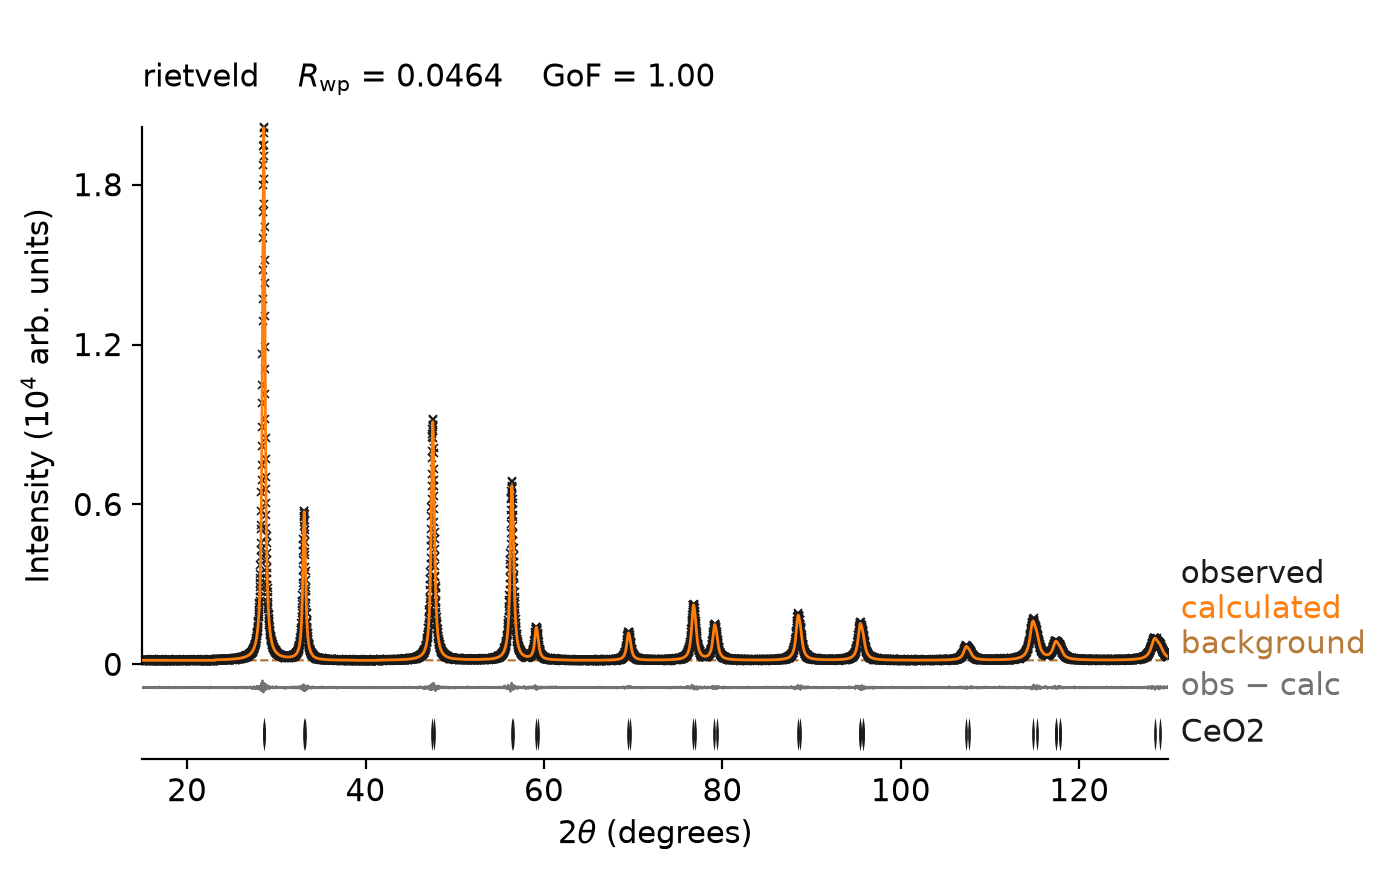

In [7]:
result.plot()

## Checking an agent's work

When an agent reports a crystallite size or a strain, check these.
The rules are in the rietx agent skill (`SKILL.md` §4b, the microstructure row).

- **Was the instrument calibrated on a standard?** Without it, the size and strain absorb the instrument's broadening, and Rwp cannot show it. Ask which standard, and whether its cell was held.
- **Every reading with its esd.** A reading whose esd is larger than its value was not measured.
- **Do the Gaussian and Lorentzian readings agree?** When both are measured, `result.microstructure[0].size_agreement` compares them, and 1 means they agree.
- **Is the size quoted as an order of magnitude, with its Scherrer constant?**
- **Size and strain need a wide 2θ range** to be told apart, because 1/cos θ and tan θ look alike over a narrow one.